In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

vertices = [
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
]

edges = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
]


In [4]:
margin = 100
x_range = np.arange(-margin, width + margin)
y_range = np.arange(-margin, height + margin)

In [5]:
def map_to_grid(x, y):
    ix = margin + x
    iy = margin + y
    return ix, iy

def map_from_grid(ix, iy):
    x = ix - margin
    y = iy - margin
    return x, y
    

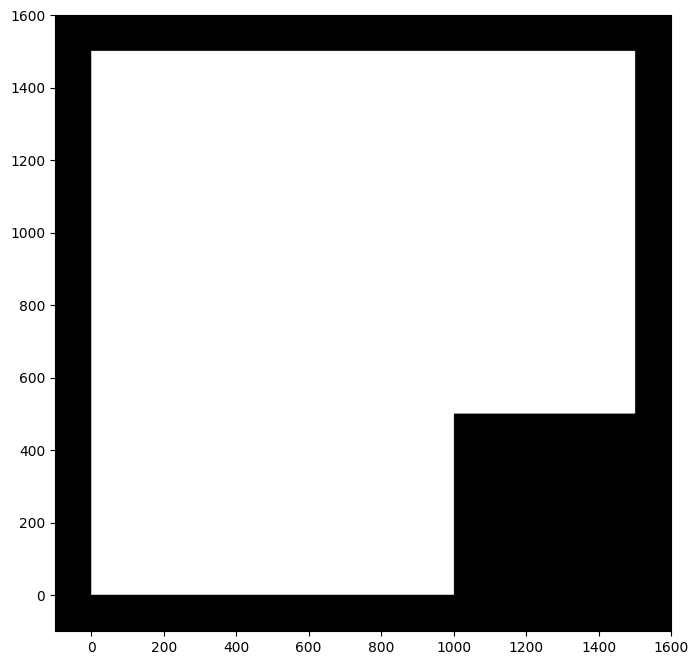

In [8]:
inside_boundary_field = np.zeros((x_range.size, y_range.size))

for grid_x in range(inside_boundary_field.shape[0]):
    # All y indices for this row
    grid_y = np.arange(inside_boundary_field.shape[1])
    x_val, y_val = map_from_grid(grid_x, grid_y)
    main_mask = (x_val >= 0) & (x_val <= width) & (y_val >= 0) & (y_val <= height)
    cutout_mask = (x_val > cutout_left) & (y_val < cutout_top)
    inside_mask = main_mask & (~cutout_mask)
    inside_boundary_field[grid_x, inside_mask] = 1

plt.figure(figsize=(8, 8))
plt.gca().set_facecolor('black')

plt.xlim(-margin, width + margin)
plt.ylim(-margin, height + margin)

plt.imshow(
    inside_boundary_field.T,
    cmap='gray',
    origin='lower',
    extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]]
)

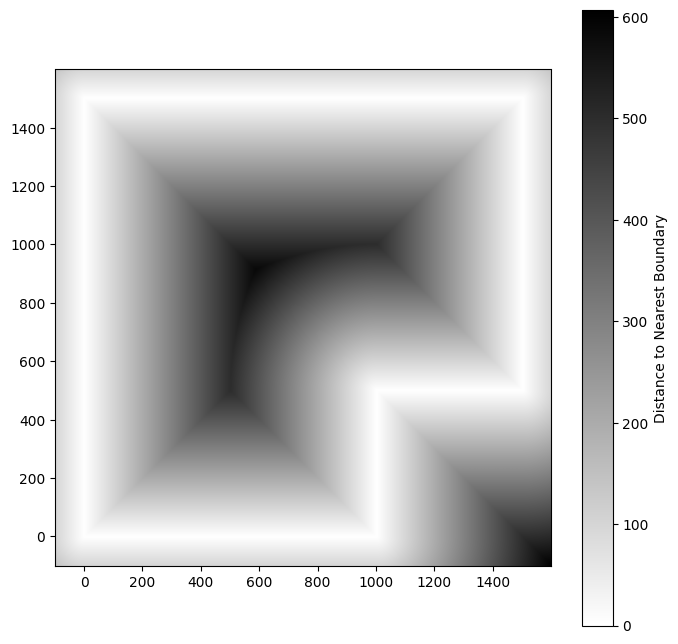

In [ ]:
# Prepare arrays to hold distances for each edge
distances = np.empty((len(edges), y_range.size, x_range.size))

def extract_vertice_deltas(edge, vertices, translate=(0, 0)):
    x1, y1 = vertices[edge[0]]
    x2, y2 = vertices[edge[1]]
    return x1, y1, x2 - x1, y2 - y1

def closest_point_on_segment(xx, yy, edge, vertices):
    x1, y1, dx, dy = extract_vertice_deltas(edge, vertices)
    # Vector from edge start to all points
    px = xx - x1
    py = yy - y1
    # Project points onto edge, clamp t to [0,1]
    denom = dx*dx + dy*dy
    t = np.where(denom != 0, (px*dx + py*dy) / denom, 0)
    t = np.clip(t, 0, 1)
    # Closest point on edge
    closest_x = x1 + t * dx
    closest_y = y1 + t * dy
    return closest_x, closest_y

for i, edge in enumerate(edges):
    closest_x, closest_y = closest_point_on_segment(xx, yy, edge, vertices)
    # Distance from each point to closest point on edge
    distances[i] = np.hypot(xx - closest_x, yy - closest_y)

# Minimum distance to any edge for each point
min_distances = np.min(distances, axis=0)
# Plot this distance field
plt.figure(figsize=(8, 8))
plt.imshow(
    min_distances,
    cmap='gray_r',
    origin='lower',
    extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]]
)
plt.colorbar(label='Distance to Nearest Boundary')

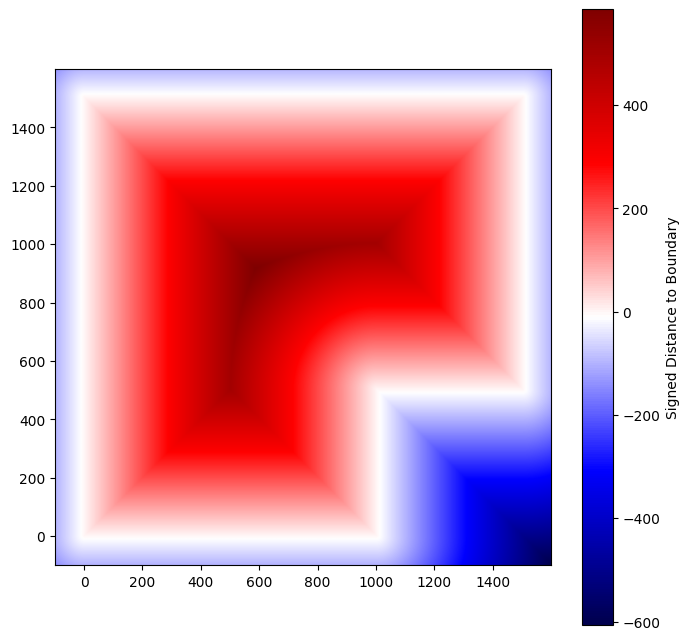

In [36]:
# Combine inside_boundary_field and min_distances
# Such that
# Where we are outside the boundary using inside_boundary_field, the distance is negative
combined_field = np.where(
    inside_boundary_field == 1,
    min_distances,  # Inside the boundary, keep distance positive
    -min_distances  # Outside the boundary, make distance negative
)

plt.figure(figsize=(8, 8))
plt.imshow(
    combined_field,
    cmap='seismic',
    origin='lower',
    extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]]
)
plt.colorbar(label='Signed Distance to Boundary')

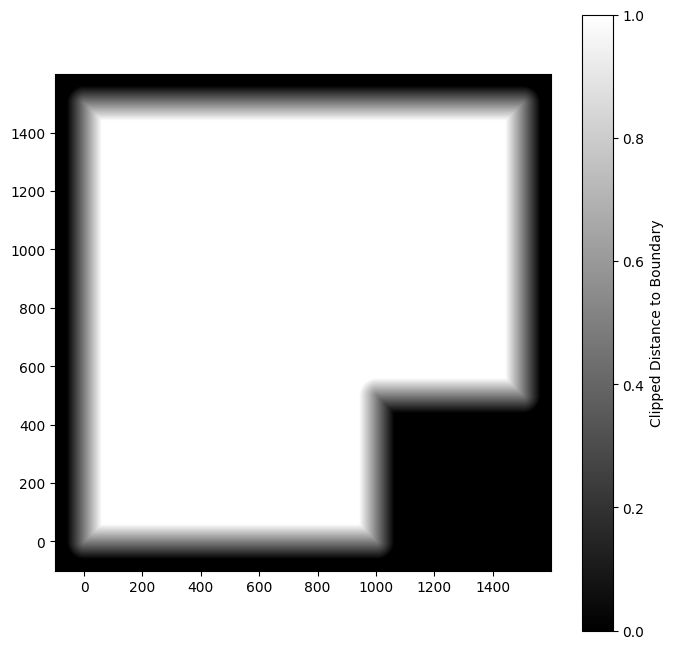

In [ ]:
# Clip the combined field to a range of -span to +span
span = 60 # pixels
clipped_field = np.clip(combined_field, -span, span)
# Normalize to [0, 1]
normalized_field = (clipped_field + span) / (2 * span)
# Plot the normalized probability field
plt.figure(figsize=(8, 8))
plt.imshow(
    normalized_field,
    cmap='gray',
    origin='lower',
    extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]]
)
plt.colorbar(label='Normalised gradient')